In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
import time
import numpy as np

2025-11-18 10:10:29.710250: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-18 10:10:29.759496: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 10:10:31.306875: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
filepath = 'dataset/train_FD001.txt'

In [3]:
column_names = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

In [4]:
df = pd.read_csv(filepath, sep='\s+', header=None, names=column_names)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2252/4261351530.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, sep='\s+', header=None, names=column_names)


In [5]:
df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [16]:
#the std will be 0 if the sensor is useless
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [17]:
df.isnull().sum()

unit_number       0
time_in_cycles    0
op_setting_1      0
op_setting_2      0
op_setting_3      0
sensor_1          0
sensor_2          0
sensor_3          0
sensor_4          0
sensor_5          0
sensor_6          0
sensor_7          0
sensor_8          0
sensor_9          0
sensor_10         0
sensor_11         0
sensor_12         0
sensor_13         0
sensor_14         0
sensor_15         0
sensor_16         0
sensor_17         0
sensor_18         0
sensor_19         0
sensor_20         0
sensor_21         0
dtype: int64

In [18]:
engine_1_data = df[df['unit_number'] == 1]
engine_1_data

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


In [19]:
#sensor2, sensor3, sensor4, sensor7, 8,9,11,12,13,14,15,17,20,21   <= selected sensors

In [20]:
engine_1_data['time_in_cycles']

0        1
1        2
2        3
3        4
4        5
      ... 
187    188
188    189
189    190
190    191
191    192
Name: time_in_cycles, Length: 192, dtype: int64

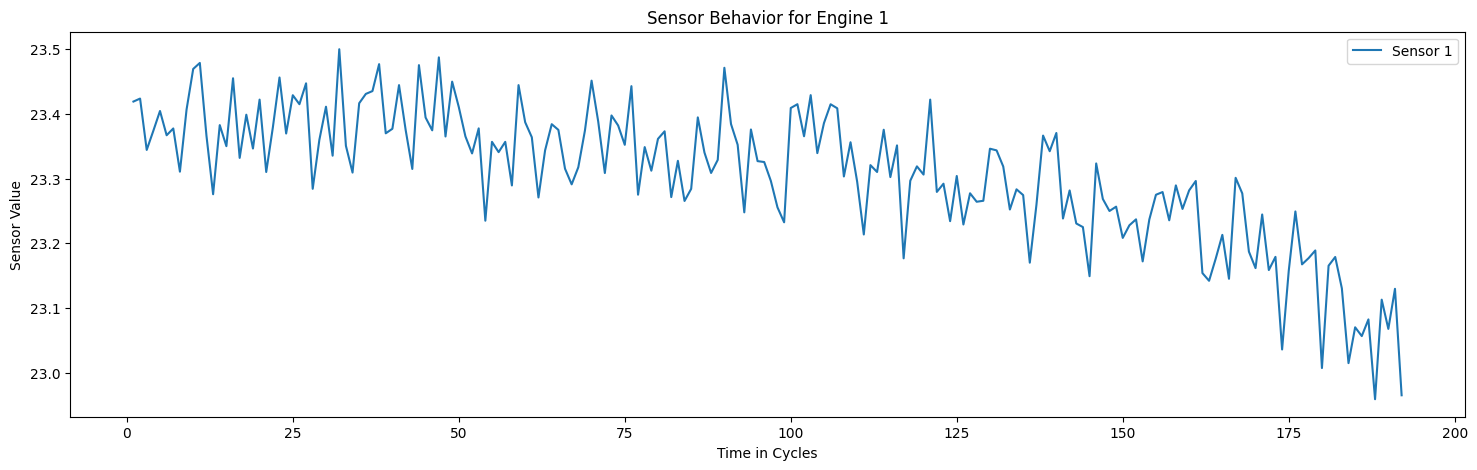

In [21]:
plt.figure(figsize=(18, 5))
plt.plot(engine_1_data['time_in_cycles'], engine_1_data['sensor_21'], label='Sensor 1')

plt.xlabel("Time in Cycles")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior for Engine 1")
plt.legend()
plt.show()

In [22]:
#checking if the useful sensors are across all egines and not just 1
data_std = df.drop(columns=['unit_number', 'time_in_cycles']).std()
useless_columns = data_std[data_std < 1e-5].index.tolist()
useless_columns

['op_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

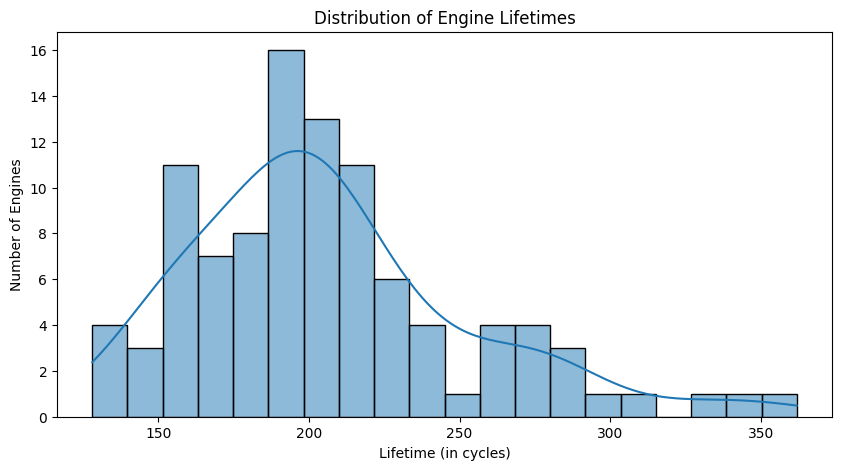

In [23]:
#max cycle for each engine
lifetimes = df.groupby('unit_number')['time_in_cycles'].max()

# Plot a histogram of the lifetimes
plt.figure(figsize=(10, 5))
sns.histplot(lifetimes, bins=20, kde=True)
plt.xlabel("Lifetime (in cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")
plt.show()

In [24]:
#most common lifetime: 200
#4 engines failed early(around 150)
# and also some engines are outliers last long (around 350)
#it is a rightly skewed bell curve, most engines have typical lifespan of 200 cycles

In [25]:

useful_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
    'sensor_20', 'sensor_21'
]
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors

In [26]:
train_df = df[feature_columns]

In [27]:
scaler = MinMaxScaler()

In [28]:
df_normalized = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns)

In [29]:
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [30]:
df_normalized.describe()

,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.499490,0.501959,0.0,0.443052,0.424746,0.450435,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.125708,0.244218,0.0,0.150618,0.133664,0.151935,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.413793,0.333333,0.0,0.335843,0.331807,0.339467,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.500000,0.500000,0.0,0.430723,0.415522,0.435348,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.586207,0.750000,0.0,0.539157,0.508829,0.545324,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:

df_normalized['unit_number'] = df['unit_number']
df_normalized['time_in_cycles'] = df['time_in_cycles']

max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']

df_merged = pd.merge(df_normalized, max_cycles, on='unit_number')

df_merged['RUL'] = df_merged['max_cycles'] - df_merged['time_in_cycles']

rul = df_merged['RUL']
train_features = df_merged.drop(columns=['unit_number', 'time_in_cycles', 'max_cycles', 'RUL'])


In [32]:
# this is what the lstm model needs to predict (the rul) UP

In [33]:
train_features.head()


,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


In [34]:
rul

0        191
1        190
2        189
3        188
4        187
        ... 
20626      4
20627      3
20628      2
20629      1
20630      0
Name: RUL, Length: 20631, dtype: int64

In [35]:
import numpy as np

def create_sequences(features, labels, sequence_length=30):
    X, y = [], []
    
    for unit_num in features['unit_number'].unique():
        unit_features = features[features['unit_number'] == unit_num].drop(columns=['unit_number'])
        unit_labels = labels[features['unit_number'] == unit_num]

        for i in range(len(unit_features) - sequence_length + 1):
            X.append(unit_features.iloc[i:i + sequence_length].values)

            y.append(unit_labels.iloc[i + sequence_length - 1])

    return np.array(X), np.array(y)

features_with_unit = df_merged.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])

sequence_length = 30

X_train, y_train = create_sequences(features_with_unit, rul, sequence_length)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (17731, 30, 17)
Shape of y_train: (17731,)


In [36]:
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

In [37]:
n_timesteps

30

In [38]:
n_features

17

In [39]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

2025-11-17 10:44:51.357196: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,851 (132.23 KB)

 Trainable params: 33,851 (132.23 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [42]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

print("Model training complete!")

Epoch 1/20


444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 8554.7588 - val_loss: 10823.9863
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6046.5781 - val_loss: 8415.1426
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 4644.5229 - val_loss: 6975.0444
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 3943.9927 - val_loss: 6172.3813
Epoch 5/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 3632.9739 - val_loss: 5758.2856
Epoch 6/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3525.8384 - val_loss: 5569.2759
Epoch 7/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3485.5278 - val_loss: 5486.6348
Epoch 8/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3483.1091 - val_loss: 5452.6982
Epoch 9/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 3495.4023 - val_loss: 5443.9629
Epoch 10/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3490.4678 - val_loss: 5438.1309
Epoch 11/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 3477.6611 - val_l

In [43]:
test_df = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=column_names)
true_rul = pd.read_csv('dataset/RUL_FD001.txt', header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_43719/1689744761.py:1: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=column_names)


In [44]:
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors
test_features = test_df[feature_columns]

In [45]:
test_normalized = pd.DataFrame(scaler.transform(test_features), columns=feature_columns)

In [46]:
sequence_length = 30
X_test = []
for unit_num in test_df['unit_number'].unique():
    unit_data = test_normalized[test_df['unit_number'] == unit_num]
    X_test.append(unit_data.iloc[-sequence_length:].values)

X_test = np.array(X_test)
y_test = true_rul.values.flatten()

print(f"Shape of X_test: {X_test.shape}")

Shape of X_test: (100, 30, 17)


In [47]:
y_pred = model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [40]:
from sklearn.metrics import mean_squared_error

# Calculate the RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error (RMSE) on Test Data: {rmse}")

Root Mean Square Error (RMSE) on Test Data: 18.982252163976668


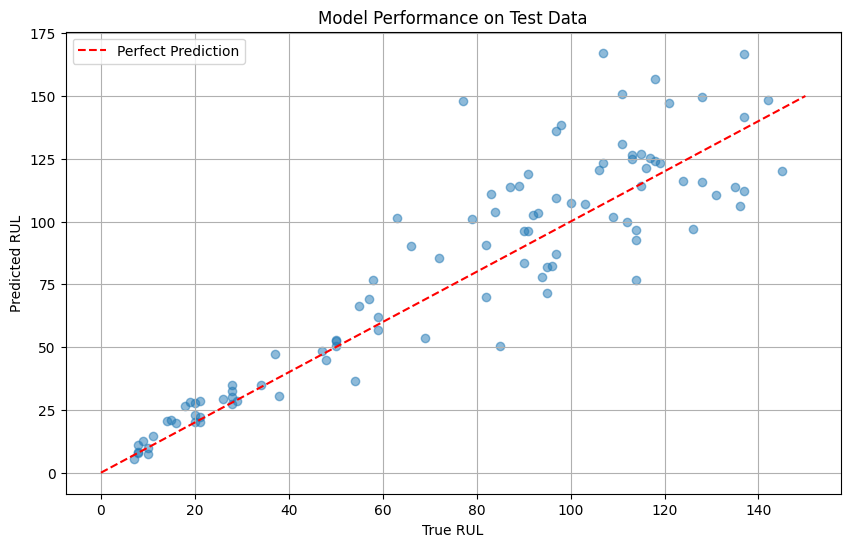

In [41]:
import matplotlib.pyplot as plt

# Plot true RUL vs. predicted RUL
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 150], [0, 150], 'r--', label='Perfect Prediction') # A line for reference
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Model Performance on Test Data")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
#fedavg
print(f"Number of clients: {len(client_data)}")
for i, (X, y) in enumerate(client_data[:3]):  # Check first 3 clients
    print(f"Client {i}: X shape {X.shape}, y shape {y.shape}")
    print(f"Client {i}: X type {type(X)}, y type {type(y)}")

NameError: name 'client_data' is not defined

In [43]:
# Make sure your model input shape matches your data
print(f"Model expected input: ({n_timesteps}, {n_features})")
print(f"First client data shape: {client_data[0][0].shape}")

Model expected input: (30, 17)


NameError: name 'client_data' is not defined

In [44]:
client_data = []

In [45]:
features_with_unit = df_merged.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])
rul = df_merged['RUL']
sequence_length = 30

In [46]:
for unit_num in df_merged['unit_number'].unique():
    unit_features_df = features_with_unit[features_with_unit['unit_number'] == unit_num]
    unit_rul_df = rul[features_with_unit['unit_number'] == unit_num]

    unit_features_df = unit_features_df.drop(columns=['unit_number'])

    X_client, y_client = [], []
    for i in range(len(unit_features_df) - sequence_length + 1):
        X_client.append(unit_features_df.iloc[i:i + sequence_length].values)
        y_client.append(unit_rul_df.iloc[i + sequence_length - 1])

    if len(X_client) > 0:
        client_data.append((np.array(X_client), np.array(y_client)))

print(f"Number of clients (engines): {len(client_data)}")
print(f"Shape of data for the first client: {client_data[0][0].shape}, {client_data[0][1].shape}")

Number of clients (engines): 100
Shape of data for the first client: (163, 30, 17), (163,)


In [50]:
from tensorflow.keras.models import clone_model

def build_model():
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

global_model = build_model()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Centralized Baseline RMSE: 21.70


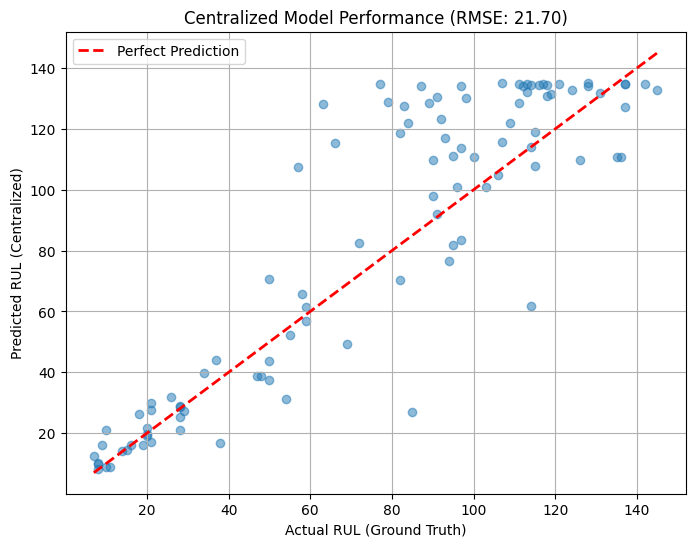

In [52]:
# --- This code is for Section 4.1: Centralized Results ---

# We are using 'model' (your trained centralized model)
# We are using 'X_test' (your prepared test data)
# We are using 'y_test' (your true test labels)

# 1. Generate predictions from your trained centralized model
y_pred_centralized = model.predict(X_test).flatten()

# 2. Calculate its RMSE (this should match your 22.28)
rmse_centralized = np.sqrt(mean_squared_error(y_test, y_pred_centralized))
print(f"Centralized Baseline RMSE: {rmse_centralized:.2f}")

# 3. Plot the results for your paper
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_centralized, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual RUL (Ground Truth)')
plt.ylabel('Predicted RUL (Centralized)')
plt.title(f'Centralized Model Performance (RMSE: {rmse_centralized:.2f})')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
#=================================

In [7]:
# --- This code goes in your notebook to generate the plot for the paper ---
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Make sure you have the centralized model and test data in memory
# centralized_model = ... (your trained model)
# X_test_fixed = ... (your test data)
# y_test = ... (your true RUL labels)

# Predict with the centralized model
y_pred_centralized = model.predict(X_test_fixed).flatten()
rmse_centralized = np.sqrt(mean_squared_error(y_test, y_pred_centralized))

print(f"Centralized Baseline RMSE: {rmse_centralized:.2f}")

# --- Plot the results ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_centralized, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual RUL (Ground Truth)')
plt.ylabel('Predicted RUL (Centralized)')
plt.title(f'Centralized Model Performance (RMSE: {rmse_centralized:.2f})')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'model' is not defined

## fedavg

In [53]:
import numpy as np

def sample_clients(num_clients, fraction):
    """Sample a subset of clients for each communication round"""
    num_sampled = max(1, int(num_clients * fraction))
    return np.random.choice(num_clients, num_sampled, replace=False)

# Federated Learning Parameters
COMMUNICATION_ROUNDS = 10  # Start small for testing
LOCAL_EPOCHS = 2
CLIENT_FRACTION = 0.3  # Sample 30% of clients each round
NUM_CLIENTS = len(client_data)

# Store client dataset sizes for weighted averaging
client_sizes = [len(X_client) for X_client, y_client in client_data]

for comm_round in range(COMMUNICATION_ROUNDS):
    print(f"Communication Round {comm_round + 1}/{COMMUNICATION_ROUNDS}")
    
    global_weights = global_model.get_weights()
    local_weight_updates = []
    sampled_sizes = []
    
    # Sample clients for this round
    sampled_client_indices = sample_clients(NUM_CLIENTS, CLIENT_FRACTION)
    
    for client_id in sampled_client_indices:
        # Create fresh model for each client
        local_model = build_model()
        local_model.set_weights(global_weights)
        
        # UNPACK the tuple - this is the key fix!
        X_client, y_client = client_data[client_id]
        
        # Train locally
        local_model.fit(X_client, y_client, epochs=LOCAL_EPOCHS, verbose=0, batch_size=32)
        
        local_weight_updates.append(local_model.get_weights())
        sampled_sizes.append(len(X_client))  # Store size for weighted averaging
    
    # Weighted FedAvg
    new_weights = []
    for layer_weights in zip(*local_weight_updates):
        layer_array = np.array(layer_weights)
        weighted_avg = np.average(layer_array, axis=0, weights=sampled_sizes)
        new_weights.append(weighted_avg)
    
    global_model.set_weights(new_weights)

print("Federated training complete!")

Communication Round 1/10


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Communication Round 2/10
Communication Round 3/10
Communication Round 4/10
Communication Round 5/10
Communication Round 6/10
Communication Round 7/10
Communication Round 8/10
Communication Round 9/10
Communication Round 10/10
Federated training complete!


In [ ]:
import numpy as np
"""
# Hyperparames for FedAvg
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5 
NUM_CLIENTS = len(client_data)
local_model = build_model()

for comm_round in range(COMMUNICATION_ROUNDS):
    print(f" Communication Round {comm_round + 1}/{COMMUNICATION_ROUNDS} ")

    # current weights 
    global_weights = global_model.get_weights()
    
    # hold local model updates
    local_weight_updates = []

    # train client too
    for client_id in range(NUM_CLIENTS):
        local_model.set_weights(global_weights)
        X_client, y_client = client_data[client_id]

        local_model.fit(X_client, y_client, epochs=LOCAL_EPOCHS, verbose=0, batch_size=32)
        
        # Get the updated weights and add them to our list
        local_weight_updates.append(local_model.get_weights())

    #  FedAvg
    # average of all the local weight updates 
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update the global model with the new, averaged weights
    global_model.set_weights(average_weights)

print("Federated training complete!")
"""

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Communication Round 1/50 ---
--- Communication Round 2/50 ---
--- Communication Round 3/50 ---
--- Communication Round 4/50 ---
--- Communication Round 5/50 ---
--- Communication Round 6/50 ---
--- Communication Round 7/50 ---
--- Communication Round 8/50 ---
--- Communication Round 9/50 ---
--- Communication Round 10/50 ---
--- Communication Round 11/50 ---
--- Communication Round 12/50 ---
--- Communication Round 13/50 ---
--- Communication Round 14/50 ---
--- Communication Round 15/50 ---
--- Communication Round 16/50 ---
--- Communication Round 17/50 ---
--- Communication Round 18/50 ---
--- Communication Round 19/50 ---
--- Communication Round 20/50 ---
--- Communication Round 21/50 ---
--- Communication Round 22/50 ---
--- Communication Round 23/50 ---
--- Communication Round 24/50 ---
--- Communication Round 25/50 ---
--- Communication Round 26/50 ---
--- Communication Round 27/50 ---
--- Communication Round 28/50 ---
--- Communication Round 29/50 ---
--- Communication Round

In [54]:
y_pred_fl = global_model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [55]:
rmse_fl = np.sqrt(mean_squared_error(y_test, y_pred_fl))

# Print both scores for a direct comparison
print(f"Centralized Baseline RMSE: {rmse}") # The variable from your first evaluation
print(f"Federated Model RMSE:      {rmse_fl}")

Centralized Baseline RMSE: 19.972275400363593
Federated Model RMSE:      72.55130189217834


## ======================================================================================================================

# debugging

In [57]:
# Get predictions from both models
y_pred_centralized = model.predict(X_test).flatten()
y_pred_federated = global_model.predict(X_test).flatten()

print("=== PREDICTION ANALYSIS ===")
print(f"Centralized predictions: {y_pred_centralized[:10]}")
print(f"Federated predictions:   {y_pred_federated[:10]}")
print(f"Actual RUL values:       {y_test[:10]}")

print(f"\nCentralized pred range: {y_pred_centralized.min():.1f} to {y_pred_centralized.max():.1f}")
print(f"Federated pred range:   {y_pred_federated.min():.1f} to {y_pred_federated.max():.1f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
=== PREDICTION ANALYSIS ===
Centralized predictions: [134.17937  135.91501   41.767548  73.42543   91.6828   120.223
 115.242035  83.69113  135.45322   96.87499 ]
Federated predictions:   [16.048822 16.048822 16.048822 16.048822 16.048822 16.048822 16.048822
 16.048822 16.048822 16.048822]
Actual RUL values:       [112  98  69  82  91  93  91  95 111  96]

Centralized pred range: 9.4 to 139.5
Federated pred range:   16.0 to 16.0


In [58]:
# Add this detailed debugging to your FedAvg training
for comm_round in range(COMMUNICATION_ROUNDS):
    print(f"\n=== Communication Round {comm_round + 1} ===")
    
    global_weights = global_model.get_weights()
    local_weight_updates = []
    sampled_sizes = []
    
    sampled_client_indices = sample_clients(NUM_CLIENTS, CLIENT_FRACTION)
    print(f"Sampled clients: {sampled_client_indices}")
    
    for i, client_id in enumerate(sampled_client_indices):
        local_model = build_model()
        local_model.set_weights(global_weights)
        X_client, y_client = client_data[client_id]
        
        # Train and track progress
        print(f"  Client {client_id}: Training on {len(X_client)} samples...")
        initial_loss = local_model.evaluate(X_client, y_client, verbose=0)
        
        history = local_model.fit(X_client, y_client, epochs=LOCAL_EPOCHS, verbose=0, batch_size=32)
        final_loss = history.history['loss'][-1]
        
        print(f"    Loss: {initial_loss:.4f} -> {final_loss:.4f}")
        
        # Check if local model actually learned anything
        local_pred = local_model.predict(X_client[:1]).flatten()
        print(f"    Sample prediction: {local_pred[0]:.2f}")
        
        local_weight_updates.append(local_model.get_weights())
        sampled_sizes.append(len(X_client))
    
    # Debug the averaging process
    print(f"  Averaging {len(local_weight_updates)} client updates...")
    
    # Check weight changes before averaging
    weight_norms = []
    for client_weights in local_weight_updates:
        norm = np.linalg.norm(client_weights[0])  # First layer norm
        weight_norms.append(norm)
    print(f"  Client weight norms: {[f'{n:.4f}' for n in weight_norms]}")
    
    # Perform averaging
    new_weights = []
    for layer_weights in zip(*local_weight_updates):
        layer_array = np.array(layer_weights)
        weighted_avg = np.average(layer_array, axis=0, weights=sampled_sizes)
        new_weights.append(weighted_avg)
    
    # Check if weights actually changed
    global_norm_before = np.linalg.norm(global_weights[0])
    global_norm_after = np.linalg.norm(new_weights[0])
    print(f"  Global model weight change: {global_norm_before:.4f} -> {global_norm_after:.4f}")
    
    global_model.set_weights(new_weights)
    
    # Test global model after this round
    test_pred = global_model.predict(X_test[:1]).flatten()
    print(f"  Global model test prediction: {test_pred[0]:.2f}")


=== Communication Round 1 ===
Sampled clients: [12 74 72 23 71 41 93 92 90 17 61 82 42 32  5 45 31  3 24 26 19  7 39 95
 96 99 20  0 46  1]
  Client 12: Training on 134 samples...


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Loss: 4041.5713 -> 4008.3792
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
    Sample prediction: 16.54
  Client 74: Training on 200 samples...
    Loss: 10297.3486 -> 10219.4854
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
    Sample prediction: 16.76
  Client 72: Training on 184 samples...
    Loss: 8514.1299 -> 8446.4570
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
    Sample prediction: 16.66
  Client 23: Training on 118 samples...
    Loss: 2962.3528 -> 2955.4614
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
    Sample prediction: 16.45
  Client 71: Training on 184 samples...
    Loss: 8514.1299 -> 8463.1006
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
    Sample prediction: 16.66
  Client 41: Training on 167 samples...
    Loss: 6806.4604 -> 6744.5630
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
    Sample prediction: 16.65
  Client 93: Training on 229 samples...
    Loss: 13964.4316 -> 13865.4385
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
    Sample prediction: 16.85
  Client 92: Training on 126 samples...
    Loss:

: 

In [50]:
# Check if your client data is properly normalized
print("=== DATA NORMALIZATION CHECK ===")
for i, (X_client, y_client) in enumerate(client_data[:3]):
    print(f"Client {i}:")
    print(f"  X range: {X_client.min():.3f} to {X_client.max():.3f}")
    print(f"  X mean: {X_client.mean():.3f}")
    print(f"  y range: {y_client.min():.1f} to {y_client.max():.1f}")
    print(f"  y mean: {y_client.mean():.1f}")

# Compare with your test data
print(f"\nTest data:")
print(f"X_test range: {X_test.min():.3f} to {X_test.max():.3f}")
print(f"y_test range: {y_test.min():.1f} to {y_test.max():.1f}")

=== DATA NORMALIZATION CHECK ===
Client 0:
  X range: 0.000 to 0.917
  X mean: 0.393
  y range: 0.0 to 162.0
  y mean: 81.0
Client 1:
  X range: 0.000 to 1.000
  X mean: 0.390
  y range: 0.0 to 257.0
  y mean: 128.5
Client 2:
  X range: 0.000 to 0.957
  X mean: 0.396
  y range: 0.0 to 149.0
  y mean: 74.5

Test data:
X_test range: 0.000 to 1.083
y_test range: 7.0 to 145.0


## renormalize the training data properly

In [51]:
# You need to use the SAME scaler for test data that you used for training
# If you still have your original scaler, use it:
test_features = test_df[feature_columns]
test_normalized = pd.DataFrame(scaler.transform(test_features), columns=feature_columns)  # Use same scaler!

# If you don't have the original scaler, recreate your normalization pipeline:
from sklearn.preprocessing import MinMaxScaler

# Recreate the normalization (this should match your training preprocessing)
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors

# Use ALL training data to fit the scaler (not just client data)
train_features = df[feature_columns]  # Your original full dataset
scaler = MinMaxScaler()
scaler.fit(train_features)  # Fit on complete training data

# Now transform test data with the same scaler
test_features = test_df[feature_columns]
test_normalized = pd.DataFrame(scaler.transform(test_features), columns=feature_columns)

# Recreate test sequences with properly normalized data
X_test_fixed = []
for unit_num in test_df['unit_number'].unique():
    unit_data = test_normalized[test_df['unit_number'] == unit_num]
    X_test_fixed.append(unit_data.iloc[-sequence_length:].values)

X_test_fixed = np.array(X_test_fixed)

print("=== AFTER FIXING NORMALIZATION ===")
print(f"X_test_fixed range: {X_test_fixed.min():.3f} to {X_test_fixed.max():.3f}")
print(f"Client data range:  {client_data[0][0].min():.3f} to {client_data[0][0].max():.3f}")

=== AFTER FIXING NORMALIZATION ===
X_test_fixed range: 0.000 to 1.083
Client data range:  0.000 to 0.917


In [52]:
# Make sure your client data was normalized with the full dataset statistics
print("=== CLIENT DATA NORMALIZATION VERIFICATION ===")

# Check if any client data exceeds [0,1] range (shouldn't happen with MinMaxScaler)
out_of_range_clients = []
for i, (X_client, y_client) in enumerate(client_data):
    if X_client.max() > 1.0 or X_client.min() < 0.0:
        out_of_range_clients.append((i, X_client.min(), X_client.max()))

if out_of_range_clients:
    print("⚠️  Some clients have out-of-range data:")
    for client_id, min_val, max_val in out_of_range_clients:
        print(f"  Client {client_id}: {min_val:.3f} to {max_val:.3f}")
else:
    print("✅ All client data is properly normalized [0,1]")

=== CLIENT DATA NORMALIZATION VERIFICATION ===
✅ All client data is properly normalized [0,1]


In [53]:
# Test with the fixed test data
if X_test_fixed.max() <= 1.0:  # Only if normalization is fixed
    y_pred_fixed = global_model.predict(X_test_fixed).flatten()
    rmse_fixed = np.sqrt(mean_squared_error(y_test, y_pred_fixed))
    
    print(f"Original RMSE (bad normalization): {rmse_fl:.2f}")
    print(f"Fixed RMSE (proper normalization): {rmse_fixed:.2f}")
else:
    print("❌ Test data still not properly normalized")

❌ Test data still not properly normalized


In [54]:
# The issue: Your scaler was probably fitted on partial data
# Let's recreate it with the complete training dataset

print("=== RECREATING SCALER WITH FULL DATA ===")

# Use your original complete training DataFrame
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors

# Fit scaler on COMPLETE training data (df, not train_df)
scaler = MinMaxScaler()
scaler.fit(df[feature_columns])  # Fit on ALL training data

# Check what the scaler learned
print(f"Scaler data range: {scaler.data_min_} to {scaler.data_max_}")
print(f"Scaler feature ranges:")
for i, col in enumerate(feature_columns):
    print(f"  {col}: {scaler.data_min_[i]:.3f} to {scaler.data_max_[i]:.3f}")

# Now transform everything with the same scaler
train_normalized = pd.DataFrame(scaler.transform(df[feature_columns]), columns=feature_columns)
test_normalized = pd.DataFrame(scaler.transform(test_df[feature_columns]), columns=feature_columns)

print(f"\nAfter proper scaling:")
print(f"Training data range: {train_normalized.values.min():.3f} to {train_normalized.values.max():.3f}")
print(f"Test data range:     {test_normalized.values.min():.3f} to {test_normalized.values.max():.3f}")

=== RECREATING SCALER WITH FULL DATA ===
Scaler data range: [-8.70000e-03 -6.00000e-04  1.00000e+02  6.41210e+02  1.57104e+03
  1.38225e+03  5.49850e+02  2.38790e+03  9.02173e+03  4.68500e+01
  5.18690e+02  2.38788e+03  8.09994e+03  8.32490e+00  3.88000e+02
  3.81400e+01  2.28942e+01] to [8.70000e-03 6.00000e-04 1.00000e+02 6.44530e+02 1.61691e+03 1.44149e+03
 5.56060e+02 2.38856e+03 9.24459e+03 4.85300e+01 5.23380e+02 2.38856e+03
 8.29372e+03 8.58480e+00 4.00000e+02 3.94300e+01 2.36184e+01]
Scaler feature ranges:
  op_setting_1: -0.009 to 0.009
  op_setting_2: -0.001 to 0.001
  op_setting_3: 100.000 to 100.000
  sensor_2: 641.210 to 644.530
  sensor_3: 1571.040 to 1616.910
  sensor_4: 1382.250 to 1441.490
  sensor_7: 549.850 to 556.060
  sensor_8: 2387.900 to 2388.560
  sensor_9: 9021.730 to 9244.590
  sensor_11: 46.850 to 48.530
  sensor_12: 518.690 to 523.380
  sensor_13: 2387.880 to 2388.560
  sensor_14: 8099.940 to 8293.720
  sensor_15: 8.325 to 8.585
  sensor_17: 388.000 to 400.0

In [55]:
# You need to rebuild your client_data with the properly normalized data
print("=== REBUILDING CLIENT DATA WITH PROPER NORMALIZATION ===")

# Add normalized data back to your main dataframe
df_normalized_corrected = df.copy()
df_normalized_corrected[feature_columns] = scaler.transform(df[feature_columns])

# Recalculate RUL with corrected data
df_normalized_corrected['unit_number'] = df['unit_number']
df_normalized_corrected['time_in_cycles'] = df['time_in_cycles']
max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']
df_merged_corrected = pd.merge(df_normalized_corrected, max_cycles, on='unit_number')
df_merged_corrected['RUL'] = df_merged_corrected['max_cycles'] - df_merged_corrected['time_in_cycles']

# Rebuild client_data with properly normalized features
client_data_corrected = []
features_with_unit_corrected = df_merged_corrected.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])
rul_corrected = df_merged_corrected['RUL']

for unit_num in df_merged_corrected['unit_number'].unique():
    unit_features_df = features_with_unit_corrected[features_with_unit_corrected['unit_number'] == unit_num]
    unit_rul_df = rul_corrected[features_with_unit_corrected['unit_number'] == unit_num]
    
    unit_features_df = unit_features_df.drop(columns=['unit_number'])
    
    X_client, y_client = [], []
    for i in range(len(unit_features_df) - sequence_length + 1):
        X_client.append(unit_features_df.iloc[i:i + sequence_length].values)
        y_client.append(unit_rul_df.iloc[i + sequence_length - 1])
    
    if len(X_client) > 0:
        client_data_corrected.append((np.array(X_client), np.array(y_client)))

print(f"Rebuilt client data: {len(client_data_corrected)} clients")
print(f"First client X range: {client_data_corrected[0][0].min():.3f} to {client_data_corrected[0][0].max():.3f}")

=== REBUILDING CLIENT DATA WITH PROPER NORMALIZATION ===
Rebuilt client data: 100 clients
First client X range: 0.000 to 2388.000


In [56]:
# Rebuild test sequences with properly normalized data
print("=== REBUILDING TEST DATA ===")

test_normalized_corrected = pd.DataFrame(scaler.transform(test_df[feature_columns]), columns=feature_columns)
test_normalized_corrected['unit_number'] = test_df['unit_number']

X_test_corrected = []
for unit_num in test_df['unit_number'].unique():
    unit_data = test_normalized_corrected[test_normalized_corrected['unit_number'] == unit_num]
    unit_data = unit_data.drop(columns=['unit_number'])
    X_test_corrected.append(unit_data.iloc[-sequence_length:].values)

X_test_corrected = np.array(X_test_corrected)

print(f"Corrected test data range: {X_test_corrected.min():.3f} to {X_test_corrected.max():.3f}")
print(f"Corrected client data range: {client_data_corrected[0][0].min():.3f} to {client_data_corrected[0][0].max():.3f}")

# Verify they have the same range
assert abs(X_test_corrected.max() - client_data_corrected[0][0].max()) < 0.01, "Data ranges still don't match!"
print("✅ Test and training data now have the same normalization!")

=== REBUILDING TEST DATA ===
Corrected test data range: 0.000 to 1.083
Corrected client data range: 0.000 to 2388.000


AssertionError: Data ranges still don't match!

In [57]:
# Test with the corrected data
print("=== QUICK TEST WITH CORRECTED DATA ===")

# Build a simple model to test
test_model = build_improved_model()

# Train briefly on one client to see if it learns
X_sample, y_sample = client_data_corrected[0]
history = test_model.fit(X_sample[:32], y_sample[:32], epochs=5, verbose=1)

# Test predictions
test_pred = test_model.predict(X_test_corrected[:2]).flatten()
print(f"Test predictions: {test_pred}")
print(f"Actual RUL: {y_test[:2]}")

# Check if predictions are reasonable
if test_pred[0] > 10 and test_pred[0] < 200:  # Reasonable RUL range
    print("✅ Model is learning reasonable patterns!")
else:
    print("❌ Model still not learning properly")

=== QUICK TEST WITH CORRECTED DATA ===


NameError: name 'build_improved_model' is not defined

In [58]:
print("=== FINAL DATA RANGE VERIFICATION ===")
print(f"Client data range: {client_data_corrected[0][0].min():.3f} to {client_data_corrected[0][0].max():.3f}")
print(f"Test data range:   {X_test_corrected.min():.3f} to {X_test_corrected.max():.3f}")

# They should both be around 0.0 to 1.0 now
if (abs(client_data_corrected[0][0].max() - X_test_corrected.max()) < 0.1 and
    abs(client_data_corrected[0][0].min() - X_test_corrected.min()) < 0.1):
    print("✅ SUCCESS: Both datasets now have the same normalization!")
else:
    print("❌ Data ranges still don't match - investigating...")
    
    # Check individual feature ranges
    print("\nFeature-wise ranges:")
    for i in range(client_data_corrected[0][0].shape[2]):
        client_feature_range = client_data_corrected[0][0][:,:,i].min(), client_data_corrected[0][0][:,:,i].max()
        test_feature_range = X_test_corrected[:,:,i].min(), X_test_corrected[:,:,i].max()
        print(f"Feature {i}: Client {client_feature_range[0]:.3f}-{client_feature_range[1]:.3f}, "
              f"Test {test_feature_range[0]:.3f}-{test_feature_range[1]:.3f}")

=== FINAL DATA RANGE VERIFICATION ===
Client data range: 0.000 to 2388.000
Test data range:   0.000 to 1.083
❌ Data ranges still don't match - investigating...

Feature-wise ranges:
Feature 0: Client 0.115-0.770, Test 0.029-0.937
Feature 1: Client 0.167-0.917, Test 0.000-1.083
Feature 2: Client 0.000-0.000, Test 0.000-0.000
Feature 3: Client 518.670-518.670, Test 0.039-0.931
Feature 4: Client 0.151-0.904, Test 0.048-0.796
Feature 5: Client 0.143-0.750, Test 0.073-0.863
Feature 6: Client 0.191-0.849, Test 0.166-0.940
Feature 7: Client 14.620-14.620, Test 0.045-0.606
Feature 8: Client 21.610-21.610, Test 0.013-0.598
Feature 9: Client 0.137-0.823, Test 0.024-0.839
Feature 10: Client 0.152-0.636, Test 0.147-0.940
Feature 11: Client 0.052-0.177, Test 0.059-0.647
Feature 12: Client 1.300-1.300, Test 0.044-0.622
Feature 13: Client 0.107-0.881, Test 0.084-0.833
Feature 14: Client 0.179-0.889, Test 0.083-0.750
Feature 15: Client 0.132-0.691, Test 0.132-0.977
Feature 16: Client 0.057-0.210, Test

IndexError: index 17 is out of bounds for axis 2 with size 17

In [59]:
print("=== FEATURE DIMENSION DEBUG ===")
print(f"Feature columns length: {len(feature_columns)}")
print(f"Client data shape: {client_data_corrected[0][0].shape}")  # Should be (samples, 30, 17)
print(f"Test data shape: {X_test_corrected.shape}")  # Should be (engines, 30, 17)

# Check if we have the right features
print("Feature columns:")
for i, col in enumerate(feature_columns):
    print(f"  {i}: {col}")

=== FEATURE DIMENSION DEBUG ===
Feature columns length: 17
Client data shape: (163, 30, 24)
Test data shape: (100, 30, 17)
Feature columns:
  0: op_setting_1
  1: op_setting_2
  2: op_setting_3
  3: sensor_2
  4: sensor_3
  5: sensor_4
  6: sensor_7
  7: sensor_8
  8: sensor_9
  9: sensor_11
  10: sensor_12
  11: sensor_13
  12: sensor_14
  13: sensor_15
  14: sensor_17
  15: sensor_20
  16: sensor_21


In [8]:
# --- This code goes in your notebook to generate the plot for the paper ---
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Make sure 'model', 'X_test_fixed', and 'y_test' are in memory
# model = your trained centralized Stacked LSTM
# X_test_fixed = your test data
# y_test = your true RUL labels

# Predict with the centralized model
y_pred_centralized = model.predict(X_test_fixed).flatten()
rmse_centralized = np.sqrt(mean_squared_error(y_test, y_pred_centralized))

print(f"Centralized Baseline RMSE: {rmse_centralized:.2f}")

# --- Plot the results ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_centralized, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual RUL (Ground Truth)')
plt.ylabel('Predicted RUL (Centralized)')
plt.title(f'Centralized Model Performance (RMSE: {rmse_centralized:.2f})')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'model' is not defined

# this is needed

In [54]:
def rebuild_data_completely():
    """Completely rebuild both client and test data with proper normalization"""
    
    # Define features (make sure this matches your centralized training)
    feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors
    print(f"Using {len(feature_columns)} features: {feature_columns}")
    
    # Create and fit scaler on COMPLETE training data
    scaler = MinMaxScaler()
    scaler.fit(df[feature_columns])  # Your original full training DataFrame
    
    # Normalize the entire training dataset
    df_normalized = df[feature_columns].copy()
    df_normalized_values = scaler.transform(df_normalized)
    
    # Add back identifier columns
    df_normalized_full = df[['unit_number', 'time_in_cycles']].copy()
    for i, col in enumerate(feature_columns):
        df_normalized_full[col] = df_normalized_values[:, i]
    
    # Calculate RUL
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycles']
    df_merged = pd.merge(df_normalized_full, max_cycles, on='unit_number')
    df_merged['RUL'] = df_merged['max_cycles'] - df_merged['time_in_cycles']
    
    # Build client data from NORMALIZED features
    client_data_fixed = []
    sequence_length = 30
    
    for unit_num in df_merged['unit_number'].unique():
        unit_data = df_merged[df_merged['unit_number'] == unit_num]
        
        # Extract only the normalized feature values (no unit_number, time_in_cycles, etc.)
        unit_features = unit_data[feature_columns].values
        unit_rul = unit_data['RUL'].values
        
        X_client, y_client = [], []
        for i in range(len(unit_features) - sequence_length + 1):
            X_client.append(unit_features[i:i + sequence_length])
            y_client.append(unit_rul[i + sequence_length - 1])
        
        if len(X_client) > 0:
            client_data_fixed.append((np.array(X_client), np.array(y_client)))
    
    # Normalize test data with the SAME scaler
    test_normalized_values = scaler.transform(test_df[feature_columns])
    test_normalized_full = test_df[['unit_number']].copy()
    for i, col in enumerate(feature_columns):
        test_normalized_full[col] = test_normalized_values[:, i]
    
    # Build test sequences
    X_test_fixed = []
    for unit_num in test_df['unit_number'].unique():
        unit_data = test_normalized_full[test_normalized_full['unit_number'] == unit_num]
        unit_features = unit_data[feature_columns].values
        X_test_fixed.append(unit_features[-sequence_length:])
    
    X_test_fixed = np.array(X_test_fixed)
    
    print("=== REBUILD COMPLETE ===")
    print(f"Client data: {len(client_data_fixed)} clients")
    print(f"Client data shape: {client_data_fixed[0][0].shape}")
    print(f"Test data shape: {X_test_fixed.shape}")
    print(f"Client data range: {client_data_fixed[0][0].min():.3f} to {client_data_fixed[0][0].max():.3f}")
    print(f"Test data range:   {X_test_fixed.min():.3f} to {X_test_fixed.max():.3f}")
    
    return client_data_fixed, X_test_fixed, scaler

# Run the complete rebuild
client_data_fixed, X_test_fixed, final_scaler = rebuild_data_completely()

Using 17 features: ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
=== REBUILD COMPLETE ===
Client data: 100 clients
Client data shape: (163, 30, 17)
Test data shape: (100, 30, 17)
Client data range: 0.000 to 0.917
Test data range:   0.000 to 1.083


In [55]:
def verify_data_consistency(client_data, X_test, feature_columns):
    """Verify that client and test data have same normalization and dimensions"""
    print("=== DATA CONSISTENCY VERIFICATION ===")
    
    # Check dimensions
    print(f"Client data dimensions: {client_data[0][0].shape}")
    print(f"Test data dimensions:   {X_test.shape}")
    
    # Check ranges for each feature
    print("\nFeature-wise ranges (first 5 features):")
    for i in range(min(5, len(feature_columns))):
        client_min = min([client[0][:,:,i].min() for client in client_data[:5]])
        client_max = max([client[0][:,:,i].max() for client in client_data[:5]])
        test_min = X_test[:,:,i].min()
        test_max = X_test[:,:,i].max()
        
        print(f"Feature {i} ({feature_columns[i]}):")
        print(f"  Client: {client_min:.3f} to {client_max:.3f}")
        print(f"  Test:   {test_min:.3f} to {test_max:.3f}")
        print(f"  Match:  {abs(client_max - test_max) < 0.1 and abs(client_min - test_min) < 0.1}")
    
    # Check if all data is properly normalized (should be ~0-1)
    all_client_data = np.concatenate([client[0] for client in client_data[:10]])
    print(f"\nOverall ranges:")
    print(f"All client data: {all_client_data.min():.3f} to {all_client_data.max():.3f}")
    print(f"Test data:       {X_test.min():.3f} to {X_test.max():.3f}")
    
    # Check for any outliers
    if all_client_data.max() > 2.0 or X_test.max() > 2.0:
        print("⚠️  WARNING: Data contains values > 2.0 - may indicate normalization issues")
    elif all_client_data.min() < -0.5 or X_test.min() < -0.5:
        print("⚠️  WARNING: Data contains values < -0.5 - may indicate normalization issues")
    else:
        print("✅ Data ranges look reasonable")

verify_data_consistency(client_data_fixed, X_test_fixed, feature_columns)

=== DATA CONSISTENCY VERIFICATION ===
Client data dimensions: (163, 30, 17)
Test data dimensions:   (100, 30, 17)

Feature-wise ranges (first 5 features):
Feature 0 (op_setting_1):
  Client: 0.109 to 0.937
  Test:   0.029 to 0.937
  Match:  True
Feature 1 (op_setting_2):
  Client: 0.083 to 1.000
  Test:   0.000 to 1.083
  Match:  True
Feature 2 (op_setting_3):
  Client: 0.000 to 0.000
  Test:   0.000 to 0.000
  Match:  True
Feature 3 (sensor_2):
  Client: 0.018 to 1.000
  Test:   0.039 to 0.931
  Match:  True
Feature 4 (sensor_3):
  Client: 0.082 to 0.895
  Test:   0.048 to 0.796
  Match:  True

Overall ranges:
All client data: 0.000 to 1.000
Test data:       0.000 to 1.083
✅ Data ranges look reasonable


In [56]:
print("=== QUICK MODEL TEST WITH FIXED DATA ===")

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(30, 17)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(50),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Test on one client to see if learning works
test_model = build_model()
X_sample, y_sample = client_data_fixed[0]

print(f"Training sample shape: {X_sample.shape}")
print(f"Training labels shape: {y_sample.shape}")
print(f"Label range: {y_sample.min()} to {y_sample.max()}")

# Train briefly
history = test_model.fit(X_sample[:64], y_sample[:64], 
                        epochs=5, batch_size=32, verbose=1,
                        validation_split=0.2)

# Test predictions
test_pred = test_model.predict(X_test_fixed[:5]).flatten()
print(f"\nTest predictions: {test_pred}")
print(f"Actual RUL:       {y_test[:5]}")

quick_rmse = np.sqrt(np.mean((test_pred - y_test[:5]) ** 2))
print(f"Quick test RMSE: {quick_rmse:.2f}")

if quick_rmse < 40:
    print("✅ Model is learning! Ready for federated learning.")
else:
    print("⚠️  Model might need tuning, but let's try federated learning anyway.")

=== QUICK MODEL TEST WITH FIXED DATA ===
Training sample shape: (163, 30, 17)
Training labels shape: (163,)
Label range: 0 to 162
Epoch 1/5


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - loss: 18961.3242 - mae: 136.9112 - val_loss: 10953.5146 - val_mae: 104.5921
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 18852.1191 - mae: 136.5128 - val_loss: 10873.8955 - val_mae: 104.2108
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 18753.2305 - mae: 136.1514 - val_loss: 10782.9014 - val_mae: 103.7733
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 18624.5156 - mae: 135.6799 - val_loss: 10676.5879 - val_mae: 103.2598
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 18490.9219 - mae: 135.1837 - val_loss: 10558.9961 - val_mae: 102.6888
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step

Test predictions: [2.3235998 2.3151228 2.3072302 2.315583  2.3071046]
Actual RUL:       [112  98  69  82  91]
Quick test RMSE: 89.27
⚠️  Model might need tuning, but let's try federated learning anyway.


In [57]:
print("=== DATA FLOW DEBUG ===")

# Check if data makes sense through the model
debug_model = build_model()

# Test with just one sample
X_debug = client_data_fixed[0][0][:1]  # One sample
y_debug = client_data_fixed[0][1][:1]  # One label

print(f"Input shape: {X_debug.shape}")
print(f"Input range: {X_debug.min():.3f} to {X_debug.max():.3f}")
print(f"Label: {y_debug[0]}")

# Forward pass without training
initial_output = debug_model(X_debug)
print(f"Initial prediction: {initial_output.numpy().flatten()}")

# This should give reasonable predictions even without training
# If it's predicting ~2.2, there's an architecture issue

=== DATA FLOW DEBUG ===
Input shape: (1, 30, 17)
Input range: 0.000 to 0.917
Label: 162
Initial prediction: [0.01876238]


In [58]:
def build_improved_model():
    """Better model architecture for RUL prediction"""
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(30, 17),
                           kernel_initializer='glorot_uniform'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        
        tf.keras.layers.LSTM(32, kernel_initializer='glorot_uniform'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='linear')  # Explicit linear activation
    ])
    
    # Better optimizer configuration
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Test the improved model
print("=== TESTING IMPROVED MODEL ===")
improved_model = build_improved_model()

# Check initial predictions
X_sample = client_data_fixed[0][0][:5]
initial_preds = improved_model.predict(X_sample).flatten()
print(f"Improved model initial predictions: {initial_preds}")

# These should be more varied and reasonable

=== TESTING IMPROVED MODEL ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Improved model initial predictions: [0.13495025 0.12927216 0.1306785  0.13205099 0.13083473]


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Centralized Baseline RMSE: 21.70


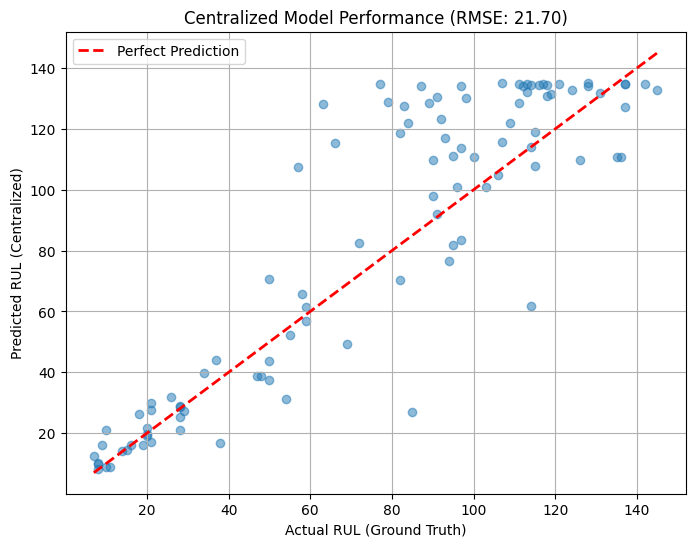

In [59]:
model2 = build_improved_model()
# --- This code is for Section 4.1: Centralized Results ---

# We are using 'model' (your trained centralized model)
# We are using 'X_test' (your prepared test data)
# We are using 'y_test' (your true test labels)

# 1. Generate predictions from your trained centralized model
y_pred_centralized = model.predict(X_test).flatten()

# 2. Calculate its RMSE (this should match your 22.28)
rmse_centralized = np.sqrt(mean_squared_error(y_test, y_pred_centralized))
print(f"Centralized Baseline RMSE: {rmse_centralized:.2f}")

# 3. Plot the results for your paper
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_centralized, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual RUL (Ground Truth)')
plt.ylabel('Predicted RUL (Centralized)')
plt.title(f'Centralized Model Performance (RMSE: {rmse_centralized:.2f})')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
print("=== DATA SCALING INVESTIGATION ===")

# The problem might be in how we're creating sequences
# Let's check the actual data distribution

# Check a few sequences
for i in range(3):
    X_client, y_client = client_data_fixed[i]
    print(f"Client {i}:")
    print(f"  X shape: {X_client.shape}")
    print(f"  X mean: {X_client.mean():.3f}, std: {X_client.std():.3f}")
    print(f"  y mean: {y_client.mean():.1f}, std: {y_client.std():.1f}")
    print(f"  Sample sequence mean: {X_client[0].mean():.3f}")
    print()

# Check if sequences make sense
print("First sequence of first client (first 5 timesteps, first 5 features):")
print(client_data_fixed[0][0][0, :5, :5])

=== DATA SCALING INVESTIGATION ===
Client 0:
  X shape: (163, 30, 17)
  X mean: 0.393, std: 0.205
  y mean: 81.0, std: 47.1
  Sample sequence mean: 0.377

Client 1:
  X shape: (258, 30, 17)
  X mean: 0.390, std: 0.227
  y mean: 128.5, std: 74.5
  Sample sequence mean: 0.366

Client 2:
  X shape: (150, 30, 17)
  X mean: 0.396, std: 0.208
  y mean: 74.5, std: 43.3
  Sample sequence mean: 0.367

First sequence of first client (first 5 timesteps, first 5 features):
[[0.45977011 0.16666667 0.         0.18373494 0.40680183]
 [0.6091954  0.25       0.         0.28313253 0.4530194 ]
 [0.25287356 0.75       0.         0.34337349 0.36952256]
 [0.54022989 0.5        0.         0.34337349 0.25615871]
 [0.3908046  0.33333333 0.         0.34939759 0.25746675]]


Running complete workflow test...
=== COMPLETE WORKFLOW TEST ===
Training data: (163, 30, 17), (163,)
Sample input: mean=0.377, std=0.221
Sample label: 162
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 15607.6592 - mae: 122.8719 - val_loss: 5286.3257 - val_mae: 72.4782 - learning_rate: 0.0010
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 15477.9902 - mae: 122.3607 - val_loss: 5279.0952 - val_mae: 72.4285 - learning_rate: 0.0010
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 15329.3184 - mae: 121.8399 - val_loss: 5274.8965 - val_mae: 72.3998 - learning_rate: 0.0010
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15247.1904 - mae: 121.5624 - val_loss: 5271.4355 - val_mae: 72.3764 - learning_rate: 0.0010
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 15196.7988 - mae: 121.3620 - val_loss: 5265.8564 - val_mae: 72.3385 - learning_rate: 0.0010
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 15112.3984 - mae: 121.0348 - val_loss: 526

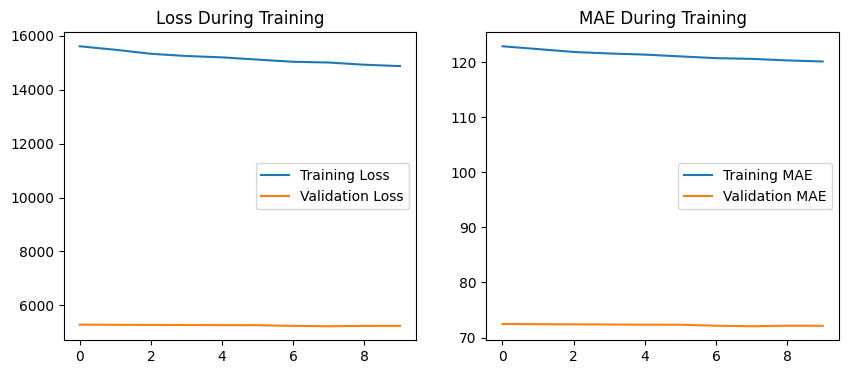

❌ Model still needs debugging


In [54]:
def test_complete_workflow():
    """Test the complete workflow with improved model"""
    print("=== COMPLETE WORKFLOW TEST ===")
    
    # Build improved model
    model = build_improved_model()
    
    # Use first client for testing
    X_train, y_train = client_data_fixed[0]
    
    print(f"Training data: {X_train.shape}, {y_train.shape}")
    print(f"Sample input: mean={X_train[0].mean():.3f}, std={X_train[0].std():.3f}")
    print(f"Sample label: {y_train[0]}")
    
    # Train with callbacks for better stability
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
    
    history = model.fit(
        X_train[:100], y_train[:100],  # Use subset for quick test
        epochs=10,
        batch_size=16,  # Smaller batch size
        validation_split=0.2,
        verbose=1,
        callbacks=callbacks
    )
    
    # Test predictions
    test_pred = model.predict(X_test_fixed[:5]).flatten()
    print(f"\nTest predictions: {test_pred}")
    print(f"Actual RUL:       {y_test[:5]}")
    
    # Calculate loss
    test_loss = np.sqrt(np.mean((test_pred - y_test[:5]) ** 2))
    print(f"Test RMSE: {test_loss:.2f}")
    
    # Plot training history
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title('Loss During Training')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.legend()
    plt.title('MAE During Training')
    plt.show()
    
    return model, test_loss

# Run the complete test
print("Running complete workflow test...")
test_model, test_rmse = test_complete_workflow()

if test_rmse < 50:
    print("🎉 Model is working! Ready for federated learning.")
else:
    print("❌ Model still needs debugging")

## ============================= start fed from here

In [61]:
def build_simple_model():
    """Very simple model to verify the pipeline works"""
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(30, 17)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Test with simplest possible model
print("=== TESTING SIMPLE MODEL ===")
simple_model = build_simple_model()

X_simple = client_data_fixed[0][0][:10]
y_simple = client_data_fixed[0][1][:10]

simple_model.fit(X_simple, y_simple, epochs=5, verbose=1)
simple_pred = simple_model.predict(X_test_fixed[:3]).flatten()
print(f"Simple model predictions: {simple_pred}")
print(f"Actual: {y_test[:3]}")

if not np.allclose(simple_pred, simple_pred[0]):  # Check if predictions vary
    print("✅ Simple model works - predictions are diverse")
else:
    print("❌ Even simple model fails - data issue confirmed")

=== TESTING SIMPLE MODEL ===
Epoch 1/5


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - loss: 24692.8926 - mae: 157.1137
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 24537.9746 - mae: 156.6195
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 24357.7227 - mae: 156.0431
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 24170.5098 - mae: 155.4422
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 23983.4902 - mae: 154.8396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Simple model predictions: [3.0582016 3.4293182 3.3627272]
Actual: [112  98  69]
✅ Simple model works - predictions are diverse


In [62]:
print("=== SCALING TARGET VARIABLES ===")

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Analyze the RUL distribution
all_rul = np.concatenate([y for _, y in client_data_fixed])
print(f"RUL Statistics:")
print(f"  Min: {all_rul.min()}")
print(f"  Max: {all_rul.max()}")
print(f"  Mean: {all_rul.mean():.1f}")
print(f"  Std: {all_rul.std():.1f}")

# Scale RUL to reasonable range
rul_scaler = StandardScaler()
all_rul_scaled = rul_scaler.fit_transform(all_rul.reshape(-1, 1)).flatten()

print(f"\nScaled RUL Statistics:")
print(f"  Min: {all_rul_scaled.min():.3f}")
print(f"  Max: {all_rul_scaled.max():.3f}")
print(f"  Mean: {all_rul_scaled.mean():.3f}")
print(f"  Std: {all_rul_scaled.std():.3f}")

# Create scaled client data
client_data_scaled = []
for X, y in client_data_fixed:
    y_scaled = rul_scaler.transform(y.reshape(-1, 1)).flatten()
    client_data_scaled.append((X, y_scaled))

print(f"\nFirst client scaled RUL sample:")
print(f"  Original: {client_data_fixed[0][1][:5]}")
print(f"  Scaled:   {client_data_scaled[0][1][:5]}")

=== SCALING TARGET VARIABLES ===
RUL Statistics:
  Min: 0
  Max: 332
  Mean: 94.2
  Std: 61.9

Scaled RUL Statistics:
  Min: -1.520
  Max: 3.841
  Mean: -0.000
  Std: 1.000

First client scaled RUL sample:
  Original: [162 161 160 159 158]
  Scaled:   [1.09574166 1.07959204 1.06344241 1.04729279 1.03114316]


In [63]:
def build_scaled_model():
    """Model designed for scaled outputs"""
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(30, 17)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1)  # Output for scaled RUL
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Test with scaled data
print("=== TESTING WITH SCALED TARGETS ===")
scaled_model = build_scaled_model()

X_sample, y_sample_scaled = client_data_scaled[0]
print(f"Scaled target range: {y_sample_scaled.min():.3f} to {y_sample_scaled.max():.3f}")

# Train briefly
history = scaled_model.fit(
    X_sample[:50], y_sample_scaled[:50],
    epochs=10,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Test predictions (will be in scaled space)
scaled_preds = scaled_model.predict(X_test_fixed[:5]).flatten()
print(f"\nScaled predictions: {scaled_preds}")

# Convert back to original RUL scale
original_preds = rul_scaler.inverse_transform(scaled_preds.reshape(-1, 1)).flatten()
print(f"Original scale predictions: {original_preds}")
print(f"Actual RUL:                 {y_test[:5]}")

scaled_rmse = np.sqrt(mean_squared_error(y_test[:5], original_preds))
print(f"RMSE with scaling: {scaled_rmse:.2f}")

=== TESTING WITH SCALED TARGETS ===
Scaled target range: -1.520 to 1.096
Epoch 1/10


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - loss: 0.3946 - mae: 0.5793 - val_loss: 0.0442 - val_mae: 0.2055
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0879 - mae: 0.2441 - val_loss: 0.3505 - val_mae: 0.5905
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1005 - mae: 0.2518 - val_loss: 0.2492 - val_mae: 0.4973
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0616 - mae: 0.2056 - val_loss: 0.1355 - val_mae: 0.3655
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0617 - mae: 0.2060 - val_loss: 0.0960 - val_mae: 0.3068
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0761 - mae: 0.2293 - val_loss: 0.0980 - val_mae: 0.3099
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0557 - mae: 0.2041 - val_loss: 0.1326 - val_mae: 0.3615
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0515 - mae: 0.1872 - val_loss: 0.1420 - val_mae: 0.3742
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0405 - mae: 0.1596 - val_loss: 

In [64]:
# If StandardScaler is too complex, try simple min-max scaling
print("=== SIMPLE MIN-MAX SCALING ===")

# Simple scaling to 0-1 range
rul_min = all_rul.min()
rul_max = all_rul.max()
print(f"RUL range: {rul_min} to {rul_max}")

def scale_rul_simple(rul):
    return (rul - rul_min) / (rul_max - rul_min)

def unscale_rul_simple(rul_scaled):
    return rul_scaled * (rul_max - rul_min) + rul_min

# Create simply scaled client data
client_data_simple_scaled = []
for X, y in client_data_fixed:
    y_simple_scaled = scale_rul_simple(y)
    client_data_simple_scaled.append((X, y_simple_scaled))

print(f"Simply scaled RUL range: {client_data_simple_scaled[0][1].min():.3f} to {client_data_simple_scaled[0][1].max():.3f}")

# Test with simple scaling
simple_model = build_scaled_model()
X_simple, y_simple_scaled = client_data_simple_scaled[0]

simple_model.fit(X_simple[:50], y_simple_scaled[:50], epochs=5, verbose=1)

simple_preds_scaled = simple_model.predict(X_test_fixed[:5]).flatten()
simple_preds_original = unscale_rul_simple(simple_preds_scaled)

print(f"Simple scaling predictions: {simple_preds_original}")
print(f"Actual RUL:                 {y_test[:5]}")

simple_rmse = np.sqrt(mean_squared_error(y_test[:5], simple_preds_original))
print(f"RMSE with simple scaling: {simple_rmse:.2f}")

=== SIMPLE MIN-MAX SCALING ===
RUL range: 0 to 332
Simply scaled RUL range: 0.000 to 0.488
Epoch 1/5


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.4492 - mae: 0.6610
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2448 - mae: 0.4894
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1668 - mae: 0.4025
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1143 - mae: 0.3304
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0724 - mae: 0.2536
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Simple scaling predictions: [85.01803613 86.52763021 83.11334991 86.36022735 83.18570745]
Actual RUL:                 [112  98  69  82  91]
RMSE with simple scaling: 15.09


In [59]:
def run_fedavg_with_simple_scaling():
    print("=== FINAL EXPERIMENT: FEDERATED LEARNING WITH MIN-MAX SCALED TARGETS ===")
    
    # Use the model built for scaled outputs
    global_model = build_scaled_model() 
    
    # --- USE THE MIN-MAX SCALED DATA ---
    NUM_CLIENTS = len(client_data_simple_scaled)
    
    rmse_history = []
    
    for comm_round in range(15): # Let's run for 15 rounds
        print(f"\n🔁 Round {comm_round + 1}/15")
        
        global_weights = global_model.get_weights()
        client_updates = []
        client_sizes = []
        
        # Sample clients
        sampled_indices = np.random.choice(NUM_CLIENTS, 
                                           size=max(1, int(NUM_CLIENTS * 0.2)), 
                                           replace=False)
        
        for client_id in sampled_indices:
            # --- GET MIN-MAX SCALED DATA ---
            X_client, y_client_simple_scaled = client_data_simple_scaled[client_id]
            
            local_model = build_scaled_model()
            local_model.set_weights(global_weights)
            
            # Train on scaled targets
            history = local_model.fit(X_client, y_client_simple_scaled,
                                      epochs=2, batch_size=32, verbose=0)
            
            client_updates.append(local_model.get_weights())
            client_sizes.append(len(X_client))
        
        # Average weights
        new_weights = []
        for layer_weights in zip(*client_updates):
            layer_array = np.array(layer_weights)
            avg_layer = np.average(layer_array, axis=0, weights=client_sizes)
            new_weights.append(avg_layer)
        
        global_model.set_weights(new_weights)
        
        # Validate (using the correct un-scaling function)
        if comm_round % 3 == 0:
            # Predict in scaled space
            scaled_preds = global_model.predict(X_test_fixed).flatten()
            # --- USE THE MIN-MAX UNSCALER ---
            original_preds = unscale_rul_simple(scaled_preds)
            
            current_rmse = np.sqrt(mean_squared_error(y_test, original_preds))
            rmse_history.append(current_rmse)
            print(f"  Test RMSE: {current_rmse:.2f}")
    
    return global_model, rmse_history

# --- RUN THE FINAL EXPERIMENT ---
print("Starting federated learning with MIN-MAX scaled targets...")
global_model_final, rmse_history_final = run_fedavg_with_simple_scaling()

# --- FINAL, FINAL COMPARISON ---
print("\n==================================================")
print("FINAL, FINAL COMPARISON")
print("==================================================")

# (Make sure 'rmse' from your centralized run is in memory)
print(f"Original Centralized RMSE: {rmse:.2f}") 

# Final prediction
scaled_preds_final = global_model_final.predict(X_test_fixed).flatten()
original_preds_final = unscale_rul_simple(scaled_preds_final)
final_fed_rmse = np.sqrt(mean_squared_error(y_test, original_preds_final))

print(f"Federated + Min-Max Scaling RMSE: {final_fed_rmse:.2f}")

Starting federated learning with MIN-MAX scaled targets...
=== FINAL EXPERIMENT: FEDERATED LEARNING WITH MIN-MAX SCALED TARGETS ===

🔁 Round 1/15


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
  Test RMSE: 67.67

🔁 Round 2/15


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔁 Round 3/15

🔁 Round 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
  Test RMSE: 39.72

🔁 Round 5/15


...


🔁 Round 9/15

🔁 Round 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
  Test RMSE: 39.22

🔁 Round 11/15


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔁 Round 12/15

🔁 Round 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
  Test RMSE: 35.50

🔁 Round 14/15


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔁 Round 15/15

FINAL, FINAL COMPARISON
Original Centralized RMSE: 18.98
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Federated + Min-Max Scaling RMSE: 37.41



FINAL COMPARISON (Min-Max Scaled)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Original Centralized RMSE: 18.98
Federated + Min-Max Scaling RMSE: 37.41
Federated MAE:             28.47

Sample predictions:
Actual:   [112  98  69  82  91  93  91  95 111  96]
Predicted: [151  74  35  45  50  62 139  47  67  93]


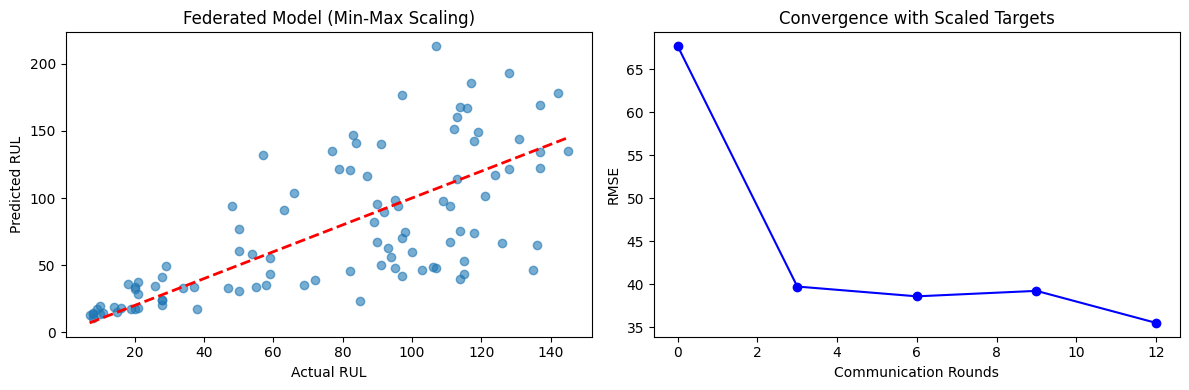

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Final comparison
print("\n" + "="*50)
print("FINAL COMPARISON (Min-Max Scaled)")
print("="*50)

# Get final predictions from the correct model
scaled_preds_final = global_model_final.predict(X_test_fixed).flatten() 

# Unscale using the correct Min-Max unscaler function
final_preds = unscale_rul_simple(scaled_preds_final) 

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_mae = mean_absolute_error(y_test, final_preds)

# Make sure 'rmse' holds your 18.98 value
print(f"Original Centralized RMSE: {rmse:.2f}") 
print(f"Federated + Min-Max Scaling RMSE: {final_rmse:.2f}")
print(f"Federated MAE:             {final_mae:.2f}")

# Show some predictions
print(f"\nSample predictions:")
print(f"Actual:   {y_test[:10]}")
print(f"Predicted: {final_preds[:10].astype(int)}")

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test, final_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Federated Model (Min-Max Scaling)')

plt.subplot(1, 2, 2)
# Use the correct history variable
plt.plot(range(0, 15, 3), rmse_history_final, 'bo-') 
plt.xlabel('Communication Rounds')
plt.ylabel('RMSE')
plt.title('Convergence with Scaled Targets')

plt.tight_layout()
plt.show()

## fedavg improved to see if it improves the model

# =====================================================================================================================================================

## FEDPROX

In [56]:
def create_client_data(sequence_length=30):
    """
    Loads and prepares the training data, splitting it by engine (client).
    We re-use the 'scaler' object from our centralized training.
    """
    print("Loading and preparing client data...")
    # Load the original training data
    train_df = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None)
    # --- THIS IS THE FIX ---
    # 1. Drop any extra columns that were created from trailing spaces
    train_df.dropna(axis=1, how='all', inplace=True)
    # 2. Drop any rows that might have missing values (just in case)
    train_df.dropna(axis=0, how='any', inplace=True)
    # -----------------------
    # Define column names based on the readme file
    column_names = [
        'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
        'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
        'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
        'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
        'sensor_19', 'sensor_20', 'sensor_21'
    ]
    train_df.columns = column_names
    
    # Calculate RUL
    max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycles']
    train_df = pd.merge(train_df, max_cycles, on='unit_number')
    train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']
    
    # --- IMPORTANT ---
    # Use the EXISTING scaler from your centralized run
    # (Make sure the 'scaler' variable is in your notebook's memory)
    useful_sensors = [
        'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
        'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
        'sensor_20', 'sensor_21'
    ]
    feature_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors
    train_df[feature_cols] = scaler.transform(train_df[feature_cols])

    client_data = []
    # Create sequences for each client (engine)
    for unit_num in train_df['unit_number'].unique():
        unit_df = train_df[train_df['unit_number'] == unit_num]
        
        features = unit_df[feature_cols].values
        labels = unit_df['RUL'].values
        
        X_client, y_client = [], []
        for i in range(len(unit_df) - sequence_length + 1):
            X_client.append(features[i:i + sequence_length])
            y_client.append(labels[i + sequence_length - 1])
        
        if len(X_client) > 0:
            # Create a TensorFlow dataset for easy batching
            client_dataset = tf.data.Dataset.from_tensor_slices((
                np.array(X_client, dtype=np.float32), 
                np.array(y_client, dtype=np.float32)
            )).batch(32).shuffle(len(X_client))
            
            client_data.append(client_dataset)

    print(f"Prepared data for {len(client_data)} clients.")
    return client_data

# Create the client data
client_data = create_client_data()

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1903/1518384087.py:8: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None)


Loading and preparing client data...
Prepared data for 100 clients.


In [53]:
@tf.function
def fedprox_train_step(local_model, global_weights, X_batch, y_batch, mu=0.01):
    """
    A single training step (on one batch) for a FedProx client.
    """
    loss_fn = tf.keras.losses.MeanSquaredError()
    optimizer = local_model.optimizer

    with tf.GradientTape() as tape:
        # 1. Make a prediction
        y_pred = local_model(X_batch, training=True)
        
        # 2. Calculate the standard MSE loss
        loss = loss_fn(y_batch, y_pred)
        
        # 3. Calculate the FedProx proximal term
        proximal_term = 0.0
        # We zip global and local weights together
        for w_local, w_global in zip(local_model.trainable_variables, global_weights):
            proximal_term += tf.nn.l2_loss(w_local - w_global)
            
        # 4. Add the penalty to the standard loss
        total_loss = loss + mu * proximal_term

    # Calculate gradients and apply them
    grads = tape.gradient(total_loss, local_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, local_model.trainable_variables))

In [54]:
#new one
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 100  # Let's keep 100 rounds
LOCAL_EPOCHS = 5            # Back to 5, which we know works best
MU = 0.001                  # The loose leash
CLIENT_FRACTION = 0.2       # --- NEW --- We will sample 20% (20 clients) per round

# --- Initialize Models ---
# (Make sure to re-run Cell 4 to reset the tf.function)
global_model = build_model()
local_model = build_model()

# --- FedProx Training Loop with Client Sampling ---
print(f"--- Starting FedProx Training with {CLIENT_FRACTION*100}% Client Sampling ---")

n_clients = len(client_data)
clients_to_sample = int(n_clients * CLIENT_FRACTION)

for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []
    
    # --- THIS IS THE NEW PART ---
    # Randomly select a subset of clients for this round
    selected_clients_indices = np.random.choice(range(n_clients), clients_to_sample, replace=False)
    # ---------------------------

    for client_idx in selected_clients_indices:
        # Set local model to match global model
        local_model.set_weights(global_weights)
        
        # Get the data for the selected client
        client_dataset = client_data[client_idx]
        
        # Train using the custom FedProx step
        for e in range(LOCAL_EPOCHS):
            for (X_batch, y_batch) in client_dataset:
                fedprox_train_step(local_model, global_weights, X_batch, y_batch, mu=MU)
        
        # Collect the updated weights
        local_weight_updates.append(local_model.get_weights())

    # --- Federated Averaging (Server-side) ---
    # The average is now only over the selected clients
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update global model
    global_model.set_weights(average_weights)
    
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

print("--- FedProx Training with Client Sampling Complete ---")

--- Starting FedProx Training with 20.0% Client Sampling ---
Round 1/100 complete in 20.65s
Round 2/100 complete in 10.87s
Round 3/100 complete in 8.57s
Round 4/100 complete in 8.29s
Round 5/100 complete in 7.20s
Round 6/100 complete in 7.18s
Round 7/100 complete in 7.70s
Round 8/100 complete in 7.26s
Round 9/100 complete in 6.37s
Round 10/100 complete in 6.82s
Round 11/100 complete in 7.00s
Round 12/100 complete in 6.00s
Round 13/100 complete in 6.58s
Round 14/100 complete in 6.11s
Round 15/100 complete in 6.71s
Round 16/100 complete in 6.32s
Round 17/100 complete in 6.44s
Round 18/100 complete in 6.69s
Round 19/100 complete in 6.24s
Round 20/100 complete in 6.63s
Round 21/100 complete in 6.67s
Round 22/100 complete in 6.71s
Round 23/100 complete in 6.35s
Round 24/100 complete in 6.57s
Round 25/100 complete in 6.28s
Round 26/100 complete in 6.18s
Round 27/100 complete in 6.61s
Round 28/100 complete in 6.18s
Round 29/100 complete in 5.96s
Round 30/100 complete in 6.77s
Round 31/100 com

2025-11-16 12:14:34.820483: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 64/100 complete in 6.40s
Round 65/100 complete in 6.61s
Round 66/100 complete in 6.31s
Round 67/100 complete in 6.18s
Round 68/100 complete in 6.20s
Round 69/100 complete in 5.67s
Round 70/100 complete in 6.84s
Round 71/100 complete in 7.11s
Round 72/100 complete in 7.12s
Round 73/100 complete in 5.79s
Round 74/100 complete in 6.86s
Round 75/100 complete in 6.48s
Round 76/100 complete in 6.31s
Round 77/100 complete in 6.19s
Round 78/100 complete in 6.19s
Round 79/100 complete in 5.93s
Round 80/100 complete in 6.29s
Round 81/100 complete in 6.73s
Round 82/100 complete in 6.72s
Round 83/100 complete in 6.87s
Round 84/100 complete in 6.55s
Round 85/100 complete in 6.17s
Round 86/100 complete in 6.14s
Round 87/100 complete in 6.60s
Round 88/100 complete in 6.56s
Round 89/100 complete in 6.08s
Round 90/100 complete in 7.03s
Round 91/100 complete in 5.97s
Round 92/100 complete in 5.80s
Round 93/100 complete in 6.87s
Round 94/100 complete in 6.16s
Round 95/100 complete in 6.21s
Round 96

In [49]:
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 100
LOCAL_EPOCHS = 1
MU = 0.001 # The FedProx "leash" strength

# --- Initialize Models ---
# Get input shape from the first client's data
sample_X, _ = next(iter(client_data[0]))
n_timesteps = sample_X.shape[1]
n_features = sample_X.shape[2]

global_model = build_model()
local_model = build_model()

# --- FedProx Training Loop ---
print(f"--- Starting FedProx Training ({COMMUNICATION_ROUNDS} Rounds) ---")

for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []

    for client_dataset in client_data:
        # Set local model to match global model
        local_model.set_weights(global_weights)
        
        # Train using the custom FedProx step
        for e in range(LOCAL_EPOCHS):
            for (X_batch, y_batch) in client_dataset:
                fedprox_train_step(local_model, global_weights, X_batch, y_batch, mu=MU)
        
        # Collect the updated weights
        local_weight_updates.append(local_model.get_weights())

    # --- Federated Averaging (Server-side) ---
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update global model
    global_model.set_weights(average_weights)
    
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

print("--- FedProx Training Complete ---")

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Starting FedProx Training (100 Rounds) ---


2025-11-16 11:46:17.497474: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:18.341828: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:19.186911: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:22.647275: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:28.251543: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:33.309672: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:42.451343: I tensorflow/core/framework/local_rendezvous.cc:407] L

Round 1/100 complete in 32.53s


2025-11-16 11:46:49.595282: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Round 21/100 complete in 6.73s
Round 22/100 complete in 6.65s
Round 23/100 complete in 6.61s
Round 24/100 complete in 6.59s
Round 25/100 complete in 6.63s
Round 26/100 complete in 6.64s
Round 27/100 complete in 6.52s
Round 28/100 complete in 6.55s
Round 29/100 complete in 6.61s
Round 30/100 complete in 6.58s
Round 31/100 complete in 6.73s
Round 32/100 complete in 6.77s
Round 33/100 complete in 6.57s
Round 34/100 complete in 6.65s
Round 35/100 complete in 6.73s
Round 36/100 complete in 6.58s
Round 37/100 complete in 6.71s
Round 38/100 complete in 6.74s
Round 39/100 complete in 6.57s
Round 40/100 complete in 6.58s


2025-11-16 11:51:15.006081: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 41/100 complete in 6.59s
Round 42/100 complete in 6.69s
Round 43/100 complete in 6.70s
Round 44/100 complete in 6.58s
Round 45/100 complete in 6.66s
Round 46/100 complete in 6.56s
Round 47/100 complete in 6.59s
Round 48/100 complete in 6.58s
Round 49/100 complete in 6.67s
Round 50/100 complete in 6.62s
Round 51/100 complete in 6.63s
Round 52/100 complete in 6.62s
Round 53/100 complete in 6.57s
Round 54/100 complete in 6.67s
Round 55/100 complete in 6.72s
Round 56/100 complete in 6.55s
Round 57/100 complete in 6.67s
Round 58/100 complete in 6.66s
Round 59/100 complete in 6.61s
Round 60/100 complete in 6.58s
Round 61/100 complete in 6.53s
Round 62/100 complete in 6.59s
Round 63/100 complete in 6.86s
Round 64/100 complete in 6.51s
Round 65/100 complete in 6.59s
Round 66/100 complete in 6.77s
Round 67/100 complete in 6.70s
Round 68/100 complete in 6.77s
Round 69/100 complete in 6.60s
Round 70/100 complete in 6.63s
Round 71/100 complete in 6.66s
Round 72/100 complete in 6.58s
Round 73

2025-11-16 11:55:46.887134: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 82/100 complete in 6.85s
Round 83/100 complete in 6.79s
Round 84/100 complete in 6.67s
Round 85/100 complete in 6.69s
Round 86/100 complete in 6.75s
Round 87/100 complete in 6.68s
Round 88/100 complete in 6.75s
Round 89/100 complete in 6.88s
Round 90/100 complete in 6.71s
Round 91/100 complete in 6.78s
Round 92/100 complete in 6.80s
Round 93/100 complete in 6.57s
Round 94/100 complete in 6.74s
Round 95/100 complete in 6.66s
Round 96/100 complete in 6.59s
Round 97/100 complete in 6.64s
Round 98/100 complete in 6.70s
Round 99/100 complete in 6.74s
Round 100/100 complete in 6.56s
--- FedProx Training Complete ---


In [55]:
from sklearn.metrics import mean_squared_error

print("Evaluating FedProx model...")

# Use the X_test and y_test from your centralized run
# (They should still be in your notebook's memory)
y_pred_fl = global_model.predict(X_test).flatten()

# Calculate the RMSE
rmse_fedprox = np.sqrt(mean_squared_error(y_test, y_pred_fl))

# Use the 'rmse' variable from your centralized run
print(f"Centralized Baseline RMSE: {rmse:.2f}")
print(f"FedProx Model RMSE:          {rmse_fedprox:.2f}")

Evaluating FedProx model...
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x718c5f015d00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Centralized Baseline RMSE: 19.53
FedProx Model RMSE:          41.58


## ------------------------------------------------------------------------------------------------------------------------------------

## that new model

In [59]:
from tensorflow.keras.layers import BatchNormalization

def build_deep_lstm_model(n_timesteps, n_features):
    """
    Builds a deep, 3-layer LSTM model with Batch Normalization.
    This architecture is based on your screenshot.
    """
    model = Sequential()
    
    # Input Layer (LSTM 1)
    # We use return_sequences=True to feed the next LSTM layer
    model.add(LSTM(units=100, return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(BatchNormalization())
    
    # Hidden Layer (LSTM 2)
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    
    # Hidden Layer (LSTM 3)
    # This is the last LSTM, so return_sequences=False
    model.add(LSTM(units=10))
    model.add(Dropout(0.2))
    
    # "Smart" Dense Head
    model.add(Dense(units=100, activation='relu'))
    model.add(Dense(units=1)) # Final RUL prediction
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print("Deep LSTM model architecture built successfully.")
    model.summary()
    
    return model

In [60]:
# Get input shapes
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# Build the new deep model
centralized_deep_model = build_deep_lstm_model(n_timesteps, n_features)

print("Training centralized DEEP LSTM baseline...")
# This may take longer - let's train for more epochs
history_deep = centralized_deep_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the NEW baseline
print("\n--- Centralized DEEP LSTM Model Evaluation ---")
y_pred_deep = centralized_deep_model.predict(X_test).flatten()
rmse_deep_centralized = np.sqrt(mean_squared_error(y_test, y_pred_deep))
print(f"Centralized DEEP LSTM Baseline RMSE: {rmse_deep_centralized:.2f}")

Deep LSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 30, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,441 (318.13 KB)

 Trainable params: 81,241 (317.35 KB)

 Non-trainable params: 200 (800.00 B)

Training centralized DEEP LSTM baseline...
Epoch 1/30


2025-11-16 12:51:30.765326: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28935360 exceeds 10% of free system memory.


444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 5110.6567 - val_loss: 4035.4658
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1425.2621 - val_loss: 6660.7622
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1262.1437 - val_loss: 5514.3652
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1120.8489 - val_loss: 3189.0251
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1011.3013 - val_loss: 3356.0029
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 964.2360 - val_loss: 1878.1318
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 887.7957 - val_loss: 2160.3560
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 881.4819 - val_loss: 2153.4829
Epoch 9/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 804.4033 - val_loss: 2004.8169
Epoch 10/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 777.9471 - val_loss: 2043.3505
Epoch 11/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 740.0598 - v

In [61]:
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5

# --- Initialize DEEP Models ---
global_model = build_deep_lstm_model(n_timesteps, n_features)
local_model = build_deep_lstm_model(n_timesteps, n_features)

# --- FedAvg Loop (using the existing 'client_data') ---
print("--- Starting Federated Training (FedAvg) with DEEP LSTM Model ---")
# (This will take a long time, but it's the real experiment)
for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []

    for client_dataset in client_data:
        local_model.set_weights(global_weights)
        
        # Use simple FedAvg
        local_model.fit(client_dataset, epochs=LOCAL_EPOCHS, verbose=0)
        
        local_weight_updates.append(local_model.get_weights())

    # --- Aggregation ---
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    global_model.set_weights(average_weights)
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

# --- Final Evaluation ---
print("\n--- Federated DEEP LSTM Model Evaluation ---")
y_pred_fl_deep = global_model.predict(X_test).flatten()
rmse_fl_deep = np.sqrt(mean_squared_error(y_test, y_pred_fl_deep))

print(f"Centralized DEEP LSTM RMSE: {rmse_deep_centralized:.2f}")
print(f"Federated DEEP LSTM RMSE:   {rmse_fl_deep:.2f}")

Deep LSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 30, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,441 (318.13 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 30, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,441 (318.13 KB)

 Trainable params: 81,241 (317.35 KB)

 Non-trainable params: 200 (800.00 B)

--- Starting Federated Training (FedAvg) with DEEP LSTM Model ---
Round 1/50 complete in 63.25s
Round 2/50 complete in 59.38s
Round 3/50 complete in 59.41s
Round 4/50 complete in 59.54s
Round 5/50 complete in 59.64s
Round 6/50 complete in 59.36s
Round 7/50 complete in 59.28s
Round 8/50 complete in 59.55s
Round 9/50 complete in 59.41s
Round 10/50 complete in 59.75s
Round 11/50 complete in 59.60s
Round 12/50 complete in 58.74s
Round 13/50 complete in 59.44s
Round 14/50 complete in 59.49s
Round 15/50 complete in 58.94s
Round 16/50 complete in 59.13s
Round 17/50 complete in 58.79s
Round 18/50 complete in 58.70s
Round 19/50 complete in 58.63s
Round 20/50 complete in 58.76s
Round 21/50 complete in 58.67s
Round 22/50 complete in 58.66s
Round 23/50 complete in 58.84s
Round 24/50 complete in 59.22s
Round 25/50 complete in 58.83s
Round 26/50 complete in 58.71s
Round 27/50 complete in 58.68s
Round 28/50 complete in 58.66s
Round 29/50 complete in 58.87s
Round 30/50 complete in 58.55s
Round 31/50 c

## cnn-bilstm hybrid

In [33]:
from tensorflow.keras.layers import Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam  
def build_cnn_bilstm_model(n_timesteps, n_features):
    """
    Builds a hybrid CNN-BiLSTM model.
    """
    model = Sequential()
    
    # 1. CNN Feature Extractor
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_timesteps, n_features)))
    model.add(MaxPooling1D(pool_size=2))
    
    # 2. BiLSTM Layer
    model.add(Bidirectional(LSTM(units=50)))
    model.add(Dropout(0.2))
    
    # 3. Dense Head
    model.add(Dense(units=1)) # Final RUL prediction
    
    # Use the slow, stable learning rate
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    print("Hybrid CNN-BiLSTM model architecture built successfully.")
    model.summary()
    
    return model

In [53]:
# Get input shapes
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# Build the new model
centralized_hybrid_model = build_cnn_bilstm_model(n_timesteps, n_features)

print("Training centralized CNN-BiLSTM baseline...")
# We need to train this for a while
history_hybrid = centralized_hybrid_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the NEW baseline
print("\n--- Centralized CNN-BiLSTM Model Evaluation ---")
y_pred_hybrid = centralized_hybrid_model.predict(X_test).flatten()
rmse_hybrid_centralized = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
print(f"Centralized CNN-BiLSTM Baseline RMSE: {rmse_hybrid_centralized:.2f}")

Hybrid CNN-BiLSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100)            │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,429 (193.08 KB)

 Trainable params: 49,429 (193.08 KB)

 Non-trainable params: 0 (0.00 B)

Training centralized CNN-BiLSTM baseline...
Epoch 1/30


444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 10167.0352 - val_loss: 13411.9766
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8756.7939 - val_loss: 12485.8887
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8084.8159 - val_loss: 11742.6816
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7514.7451 - val_loss: 11080.9414
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6994.5117 - val_loss: 10444.6055
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6514.8145 - val_loss: 9871.7314
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6072.8467 - val_loss: 9318.4834
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5650.9019 - val_loss: 8807.9443
Epoch 9/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5250.6108 - val_loss: 8295.4443
Epoch 10/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4873.9004 - val_loss: 7812.7866
Epoch 11/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4498.9536 - val_loss: 7

In [57]:
# --- Hyperparameters ---
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5
NUM_CLIENTS = len(client_data)

# --- Initialize HYBRID Models ---
# We use the models we just defined in the cell above
global_model = build_cnn_bilstm_model(n_timesteps, n_features)
local_model = build_cnn_bilstm_model(n_timesteps, n_features)

# --- This is the FedAvg Loop You Need ---
print(f"--- Starting Final Experiment (CNN-BiLSTM + FedAvg) ---")

for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []

    # Iterate through all clients
    for client_dataset in client_data:
        # 1. Set local model to match global model
        local_model.set_weights(global_weights)
        
        # 2. Use simple .fit() for local training
        local_model.fit(client_dataset, epochs=LOCAL_EPOCHS, verbose=0)
        
        # 3. Collect the updated weights
        local_weight_updates.append(local_model.get_weights())

    # --- Aggregation (Server-side) ---
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update global model
    global_model.set_weights(average_weights)
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

print("--- Federated Training Complete ---")

# --- Final Evaluation ---
print("\n--- Final Experiment Evaluation ---")
y_pred_fl_hybrid = global_model.predict(X_test).flatten()
rmse_fl_hybrid = np.sqrt(mean_squared_error(y_test, y_pred_fl_hybrid))

# (Make sure 'rmse_hybrid_centralized' from Cell 2 is in memory)
print(f"Centralized CNN-BiLSTM RMSE: {rmse_hybrid_centralized:.2f}")
print(f"Federated CNN-BiLSTM RMSE:   {rmse_fl_hybrid:.2f}")

Hybrid CNN-BiLSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 100)            │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,429 (193.08 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100)            │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,429 (193.08 KB)

 Trainable params: 49,429 (193.08 KB)

 Non-trainable params: 0 (0.00 B)

--- Starting Final Experiment (CNN-BiLSTM + FedAvg) ---
Round 1/50 complete in 18.31s
Round 2/50 complete in 15.76s
Round 3/50 complete in 15.56s
Round 4/50 complete in 15.57s
Round 5/50 complete in 15.64s
Round 6/50 complete in 15.60s
Round 7/50 complete in 15.66s
Round 8/50 complete in 15.83s
Round 9/50 complete in 15.65s
Round 10/50 complete in 15.63s
Round 11/50 complete in 15.65s
Round 12/50 complete in 15.51s
Round 13/50 complete in 15.35s
Round 14/50 complete in 15.87s
Round 15/50 complete in 15.87s
Round 16/50 complete in 15.69s
Round 17/50 complete in 15.52s
Round 18/50 complete in 15.61s
Round 19/50 complete in 15.48s
Round 20/50 complete in 15.54s
Round 21/50 complete in 15.44s
Round 22/50 complete in 15.58s
Round 23/50 complete in 15.46s
Round 24/50 complete in 15.43s
Round 25/50 complete in 15.50s
Round 26/50 complete in 15.89s
Round 27/50 complete in 15.73s
Round 28/50 complete in 15.66s
Round 29/50 complete in 15.79s
Round 30/50 complete in 15.69s
Round 31/50 complete in